In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv(
    "../../data/processed/weather_features.csv",
    parse_dates=["date"]
)

In [3]:
df.head()

,date,temperature_2m_max,temperature_2m_min,precipitation_sum,temperature_mean,humidity_mean,pressure_mean,wind_speed_mean,precipitation_hourly_sum,temperature_lag_1,temperature_lag_3,temperature_lag_7,temperature_rolling_3,temperature_rolling_7,humidity_rolling_3,pressure_rolling_3,day_of_week,month,target_next_day_max_temp
0,2022-01-08,27.6,18.0,0.3,22.000000,72.750000,1015.225000,11.425000,0.3,27.6,27.6,27.8,27.566667,27.385714,69.527778,1015.069444,5,1,28.7
1,2022-01-09,28.7,18.0,0.4,22.508333,70.583333,1013.383333,8.841667,0.4,27.6,27.5,27.1,27.966667,27.614286,70.583333,1014.523611,6,1,26.5
2,2022-01-10,26.5,18.2,3.0,21.400000,79.625000,1013.962500,7.333333,3.0,28.7,27.6,27.3,27.600000,27.500000,74.319444,1014.190278,0,1,26.6
3,2022-01-11,26.6,17.3,4.9,20.820833,82.958333,1013.758333,10.608333,4.9,26.5,27.6,27.0,27.266667,27.442857,77.722222,1013.701389,1,1,26.1
4,2022-01-12,26.1,17.0,1.5,20.275000,83.583333,1013.520833,8.545833,1.5,26.6,28.7,27.6,26.400000,27.228571,82.055556,1013.747222,2,1,24.1


In [4]:
df.shape

(1453, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      1453 non-null   datetime64[us]
 1   temperature_2m_max        1453 non-null   float64       
 2   temperature_2m_min        1453 non-null   float64       
 3   precipitation_sum         1453 non-null   float64       
 4   temperature_mean          1453 non-null   float64       
 5   humidity_mean             1453 non-null   float64       
 6   pressure_mean             1453 non-null   float64       
 7   wind_speed_mean           1453 non-null   float64       
 8   precipitation_hourly_sum  1453 non-null   float64       
 9   temperature_lag_1         1453 non-null   float64       
 10  temperature_lag_3         1453 non-null   float64       
 11  temperature_lag_7         1453 non-null   float64       
 12  temperature_rolling_3     1453 

In [6]:
df = df.sort_values("date").reset_index(drop=True)

In [8]:
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "temperature_mean",
    "humidity_mean",
    "pressure_mean",
    "wind_speed_mean",
    "precipitation_hourly_sum",
    "temperature_lag_1",
    "temperature_lag_3",
    "temperature_lag_7",
    "temperature_rolling_3",
    "temperature_rolling_7",
    "humidity_rolling_3",
    "pressure_rolling_3",
    "day_of_week",
    "month"
]

X = df[features]
y = df["target_next_day_max_temp"]

In [9]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [10]:
print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 1162
Testing: 291


In [11]:
regression_model = LinearRegression()

In [12]:
regression_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 0.45,-0.25, 0. ,...,-0.1 ,-0.03,-0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['temperature_2m_max','temperature_2m_min','precipitation_sum',..., 'pressure_rolling_3','day_of_week','month']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.499
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,16


In [13]:
regression_pred = regression_model.predict(X_test)

In [14]:
regression_mae = mean_absolute_error(y_test, regression_pred)
regression_mse = mean_squared_error(y_test, regression_pred)
regression_rmse = np.sqrt(regression_mse)
regression_r2 = r2_score(y_test, regression_pred)

In [15]:
print("Regression MAE:", regression_mae)
print("Regression MSE:", regression_mse)
print("Regression RMSE:", regression_rmse)
print("Regression R2:", regression_r2)

Regression MAE: 0.8955978634936435
Regression MSE: 1.523675310161123
Regression RMSE: 1.2343724357588042
Regression R2: 0.8712622733192007


In [16]:
joblib.dump(
    regression_model,
    "../models/regression_model.pkl"
)

['../models/regression_model.pkl']

In [17]:
temperature_series = df[
    ["date", "temperature_2m_max"]
].copy()

In [18]:
temperature_series = temperature_series.set_index("date")

In [19]:
temperature_series = temperature_series["temperature_2m_max"]

In [20]:
temperature_series.head()

date
2022-01-08    27.6
2022-01-09    28.7
2022-01-10    26.5
2022-01-11    26.6
2022-01-12    26.1
Name: temperature_2m_max, dtype: float64

In [21]:
arima_split = int(len(temperature_series) * 0.8)

arima_train = temperature_series.iloc[:arima_split]
arima_test = temperature_series.iloc[arima_split:]

In [22]:
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [23]:
arima_fitted = arima_model.fit()

In [24]:
arima_pred = arima_fitted.forecast(
    steps=len(arima_test)
)

In [25]:
arima_mae = mean_absolute_error(arima_test, arima_pred)
arima_mse = mean_squared_error(arima_test, arima_pred)
arima_rmse = np.sqrt(arima_mse)
arima_r2 = r2_score(arima_test, arima_pred)

In [26]:
print("ARIMA MAE:", arima_mae)
print("ARIMA MSE:", arima_mse)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA R2:", arima_r2)

ARIMA MAE: 5.44850187714283
ARIMA MSE: 37.22687945268122
ARIMA RMSE: 6.101383404825599
ARIMA R2: -2.1122336788614233


In [27]:
joblib.dump(
    arima_fitted,
    "../models/arima_model.pkl"
)

['../models/arima_model.pkl']

In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "ARIMA"],
    "MAE": [regression_mae, arima_mae],
    "MSE": [regression_mse, arima_mse],
    "RMSE": [regression_rmse, arima_rmse],
    "R2": [regression_r2, arima_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.895598,1.523675,1.234372,0.871262
1,ARIMA,5.448502,37.226879,6.101383,-2.112234


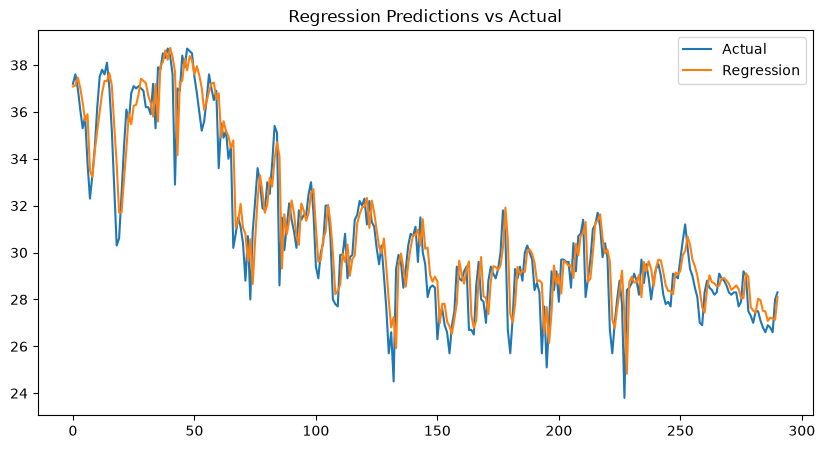

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(regression_pred, label="Regression")
plt.title("Regression Predictions vs Actual")
plt.legend()
plt.show()

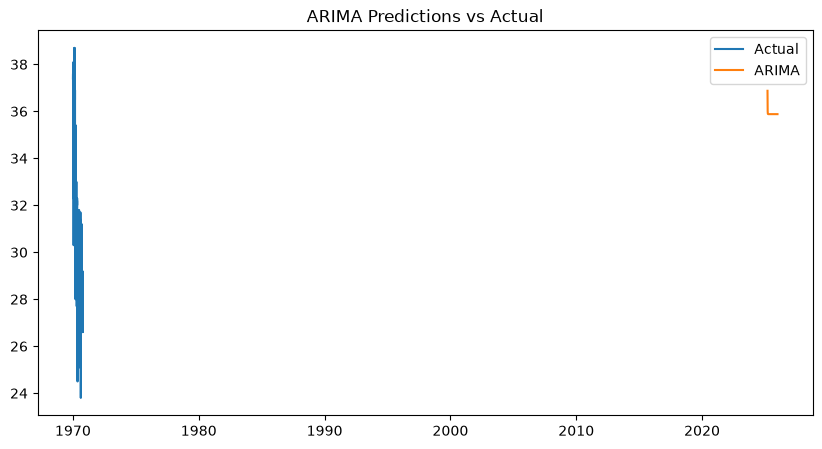

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(arima_test.values, label="Actual")
plt.plot(arima_pred, label="ARIMA")
plt.title("ARIMA Predictions vs Actual")
plt.legend()
plt.show()

In [31]:
print("Regression model:", type(regression_model).__name__)
print("ARIMA model:", type(arima_fitted).__name__)

Regression model: LinearRegression
ARIMA model: ARIMAResultsWrapper


In [32]:
comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.895598,1.523675,1.234372,0.871262
1,ARIMA,5.448502,37.226879,6.101383,-2.112234
